In [48]:
import numpy as np
import matplotlib.pyplot as plt

def exactsolution(x):
    return np.exp(-2*x)

def f(x, y):
    return -2*y

def eulerapprox(h, x_start, x_end):
    # Define parameter # step size
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Exact Solution as Reference
    y = exactsolution(x_values)
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    # Error Calcs
    y_reference = y.copy()
    x_reference = x_values.copy()
        
    ylen = min(len(y_reference), len(y_values))
    global_error = np.abs(y_values[:ylen] - y_reference[:ylen])
    local_error = np.zeros_like(x_values)

    for i in range(len(x_values)-1):
        y_true_next = exactsolution(x_values[i+1])
        y_taylor = exactsolution(x_values[i]) + h * f(x_values[i], exactsolution(x_values[i]))
        local_error[i+1] = abs(y_true_next - y_taylor)
        
    # Plot the results
    plt.plot(x_values, y_values, label="Euler's Method Approximation")
    plt.plot(x_values, local_error, label="Local Error")
    plt.plot(x_values, global_error, label="Global Error")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Approximation of dy/dx = -2y using Euler's Method for h = " +str(h))
    plt.legend()
    plt.show()


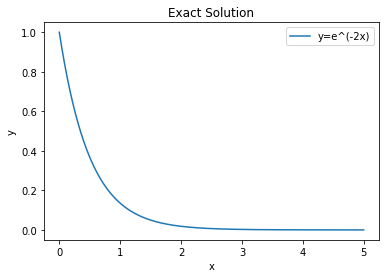

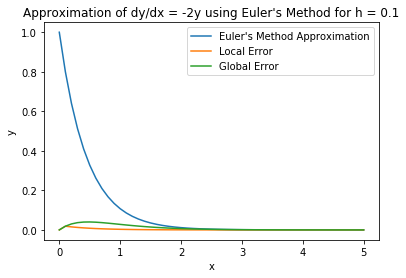

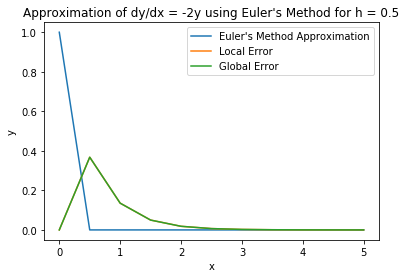

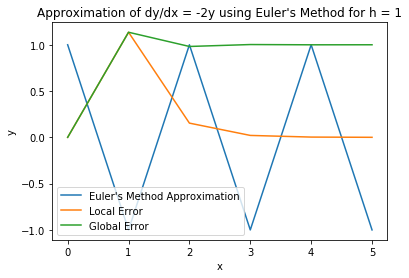

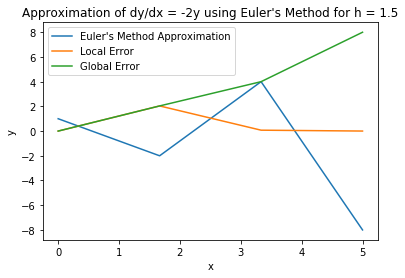

In [56]:
# Actual
x = np.linspace(0, 5, 100000)
y = exactsolution(x)
plt.plot(x, y, label="y=e^(-2x)")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Exact Solution")
plt.legend()
plt.show()

# Approximations
eulerapprox(.1,0,5)
eulerapprox(.5,0,5)
eulerapprox(1,0,5)
eulerapprox(1.5,0,5)